> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


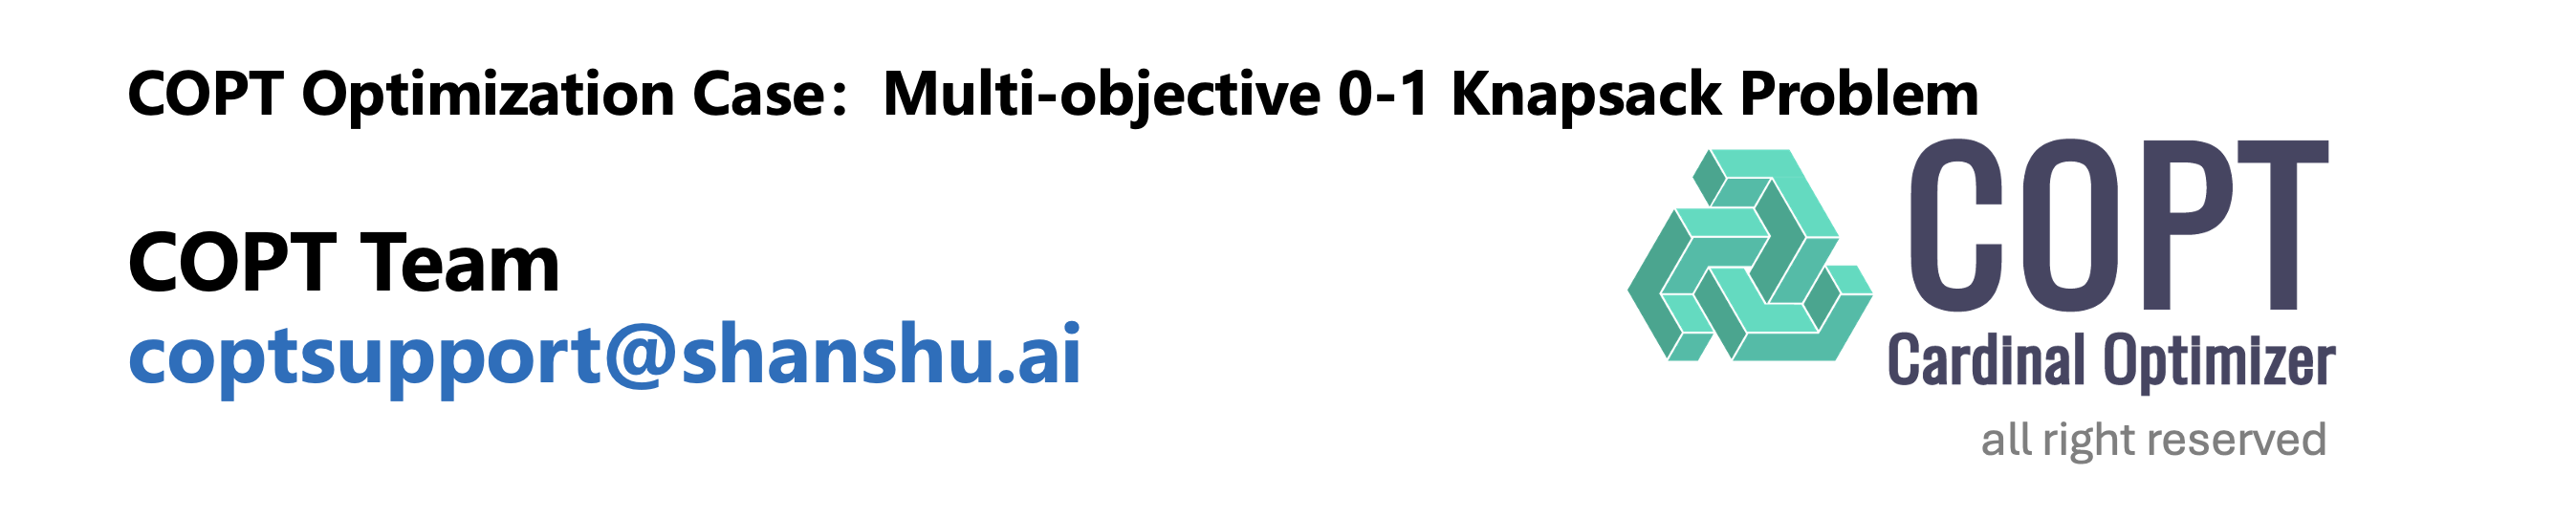

# Single-objective 0-1 Knapsack Problem Code Implementation

### Steps to Model and Solve a 0-1 Integer Program Using COPT

Firstly, let us start from the single-objective 0-1 Knapsack Problem.

The basic steps to solve a single-objective 0-1 knapsack problem in Python using COPT are as follows:

1. **Import the COPT Python API**: `coptpy`

2. **Add or import data** (optional)

3. **Create the COPT environment** and **COPT model**

4. **Build the optimization model**
   Add the three key components of the model in the following order:

   * **Decision variables**: Add 0-1 (binary) decision variables \$x\_i \in {0,1}\$ to represent whether item \$i\$ is selected, using `Model.addVar()` with the parameter `vtype=COPT.BINARY`;
   * **Objective function**: Maximize the total value of selected items \$\sum p\_i x\_i\$ using `Model.setObjective()` with the parameter `sense=COPT.MAXIMIZE`;
   * **Constraints**: Add the knapsack capacity (linear) constraint \$\sum a\_i x\_i \leq b\$ using `Model.addConstr()`.

5. **Call the COPT solver** to solve the 0-1 integer programming model

6. **View and interpret the results**


## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

## Add Model Data

Here we add the model data corresponding to the sets and parameters defined in the mathematical model, using basic built-in Python data structures.

* \$n\$: Total number of items
* \$p\_i\$: Value of item \$i\$ \$(i = 0, 1, 2, \dots, n-1)\$
* \$w\_i\$: Weight of item \$i\$
* \$v\_i\$: Volume of item \$i\$
* \$W\$: Maximum weight capacity of the knapsack
* \$V\$: Maximum volume capacity of the knapsack


In [6]:
# value
p = [9, 2, 5, 4, 90, 70, 6]   
# item amount
n = len(p)
# weight
w = [3, 15, 2, 4, 2, 14, 16]   
# volume
v = [2, 3, 1, 2, 1, 4, 3]  
# volume capacity
V = 15  
# weight limit
W = 50

## Create the COPT environment and COPT model

In [8]:
# Create COPT environment
env = cp.Envr()
# Create model object
m = env.createModel('knapsack')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



### Add the Three Core Components of the Model

#### Add Decision Variables

In the 0-1 knapsack problem, whether each item is included is represented by a binary variable:

$$
x_i =
\begin{cases}
1, & \text{If item i is selected } \\
0, & \text{Otherwise } 
\end{cases}
$$

Here, we specify the number of variables as `n` and add a batch of 0-1 binary variables (`COPT.BINARY`).

In [10]:
x = m.addVars(n, vtype=COPT.BINARY)

### Set Objective Function

The objective function of the single-objective 0-1 knapsack problem is to **maximize** (`sense=COPT.MAXIMIZE`) the total value of all items placed in the knapsack. This is a linear objective:

$$
\max \sum_{i=0}^{n-1} p_i x_i
$$

We use `Model.setObjective()` to define the objective function. The linear expression is constructed using `quicksum()`, whose syntax closely resembles the algebraic formulation.

In [12]:
# Objective 1: minimize total weight, lower priority
m.setObjective(
    cp.quicksum(p[i]*x[i] for i in range(n)),
    sense=COPT.MAXIMIZE
)

<font color=#0000FF>  
<b>Tip: It is recommended to use quicksum()</b>  
</font>  

Here we use the helper function `quicksum()` from COPT to perform summation. While it functions similarly to Python’s built-in `sum()`, `quicksum()` is optimized for performance. It is faster and more memory-efficient, especially when modeling large-scale problems, and outperforms `sum()` or using the `+` operator directly in such scenarios.

### Add Constraints

We need to satisfy both the **weight constraint** and the **volume capacity constraint**.

1. The total weight of the selected items must not exceed the knapsack's weight limit \$W\$:

$$
\sum_{i=0}^{n-1} w_i x_i \leq W
$$

We use `m.addConstr()` to add a single linear constraint. The linear expression on the left-hand side is also constructed using `cp.quicksum()`.
The coefficients `w` and the right-hand side `W` correspond to the previously defined list of item weights and the knapsack’s weight limit constant.

In [15]:
# weight constraint
m.addConstr(cp.quicksum(w[i]*x[i] for i in range(n)) <= W)

<coptpy.Constraint: >

2. The total volume of the selected items must not exceed the knapsack's volume limit \$V\$:

$$
\sum_{i=0}^{n-1} v_i x_i \leq V
$$

We use `m.addConstr()` to add this linear constraint. The left-hand side expression is similarly constructed using `cp.quicksum()`.
The coefficients `v` and the right-hand side `V` correspond to the previously defined list of item volumes and the knapsack’s volume capacity constant.

In [17]:
# volumne constraint
m.addConstr(cp.quicksum(v[i]*x[i] for i in range(n)) <= V)

<coptpy.Constraint: >

## Solve and Retrieve Results

Once the model is constructed, call the `Model.solve()` function to solve the above optimization model.

In [19]:
# Solve
m.solve()

Model fingerprint: 6c70b9e9

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    2 rows, 7 columns and 14 non-zero elements
    7 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : 184.000000000
Best bound      : 184.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :            0


In [20]:
# Output results
if m.status == COPT.OPTIMAL:
    print("Optimal total value:", m.objval)
    print("\nSelected items:")
    print("{:<6} {:<6} {:<6} {:<6}".format("Item", "Value", "Weight", "Volume"))
    print("-" * 26)
    total_value = 0
    total_weight = 0
    total_volume = 0
    for i in range(n):
        if x[i].getInfo(COPT.Info.Value) > 0.5:
            print("{:<6} {:<6} {:<6} {:<6}".format(i, p[i], w[i], v[i]))
            total_value += p[i]
            total_weight += w[i]
            total_volume += v[i]
    print("-" * 26)
    print("{:<6} {:<6} {:<6} {:<6}".format("Sum", total_value, total_weight, total_volume))
else:
    print("No optimal solution found.")

Optimal total value: 184.0

Selected items:
Item   Value  Weight Volume
--------------------------
0      9      3      2     
2      5      2      1     
3      4      4      2     
4      90     2      1     
5      70     14     4     
6      6      16     3     
--------------------------
Sum    184    41     13    


# Multi-objective 0-1 Knapsack Problem Code Implementation

### Steps to Model and Solve a Multi-objective Optimization Problem Using COPT

The basic steps to solve a multi-objective 0-1 knapsack problem in Python using COPT are as follows:

1. **Import the COPT Python API**: `coptpy`

2. **Add or import data** (optional)

3. **Create the COPT environment** and **COPT model**

4. **Build the optimization model**
   Add the three core components of the model in the following order:

   * **Decision variables**: Add 0-1 (binary) decision variables \$x\_i \in {0,1}\$ to represent whether item \$i\$ is selected, using `Model.addVar()` with `vtype=COPT.BINARY`;
   * **Objective functions**: Use `Model.setObjectiveN()` to define multiple objective functions. Use the `priority` or `weight` parameter to assign their importance:

     * **Objective 1**: Maximize the total value of items in the knapsack $\max\quad\sum p_i x_i$, with `priority=2` (higher priority);
     * **Objective 2**: Minimize the total weight of items in the knapsack $\min\quad\sum w_i x_i$, with `priority=0.1` (lower priority);
   * **Constraints**: Add the knapsack’s volume constraint $\sum v_i x_i \leq V$ using`Model.addConstr()`.

5. **Call the COPT solver** to solve the multi-objective 0-1 integer programming model

6. **View and interpret the results**


## Create the Solver Environment and Optimization Model

At the beginning, we create a new model object within the COPT environment to represent the multi-objective optimization model.

In [23]:
# Create model object
m2 = env.createModel('knapsack_multi')

## Add the Three Core Components of the Model

### Add Decision Variables

In the multi-objective 0-1 knapsack problem, the construction of decision variables is the same as in the single-objective case:

$$
x_i =
\begin{cases}
1, & \text{if item } i \text{ is selected} \\\\
0, & \text{if item } i \text{ is not selected}
\end{cases}
$$

Here, we specify the number of variables as `n` and add a batch of 0-1 binary variables (`COPT.BINARY`).

In [25]:
x = m2.addVars(n, vtype=COPT.BINARY)

## Install Dependencies
Run the cell below to install this case's requirements into the runtime. No environment switch or kernel change is needed.

In [27]:
# Objective 1: maximize total value, higher priority
m2.setObjectiveN(
    1,
    cp.quicksum(p[i]*x[i] for i in range(n)),
    priority=2.0,
    sense=COPT.MAXIMIZE
)

In [28]:
# Objective 2: minimize total weight, lower priority
m2.setObjectiveN(
    2,
    cp.quicksum(w[i]*x[i] for i in range(n)), 
    priority=1.0,
    sense=COPT.MINIMIZE
)

<font color=#0000FF>  
<b>Tip: COPT Multi-Objective Optimization Feature</b>  
</font>  

Starting from version 7.2.8, COPT supports **multi-objective optimization**, currently for **linear objective functions** (both continuous and discrete). You can define multiple objectives using the `Model.setObjectiveN()` method and assign each one a `priority` or `weight`.

When solving multi-objective models, COPT supports both the **hierarchy method** and the **weighted-sum method**.
For details, please refer to the [**COPT User Manual: Multi-Objective Optimization**](https://guide.coap.online/copt/en-doc/multiobj.html).


### Add Constraints

In the single-objective model, we needed both weight and volume constraints.
However, in the multi-objective model, since \$\min\quad\sum w\_i x\_i\$ is now one of the objectives, we only need to enforce the **volume constraint**:

The total volume of selected items must not exceed the knapsack’s volume limit \$V\$:

$$
\sum_{i=0}^{n-1} v_i x_i \leq V
$$

In [31]:
# volumne constraint
m2.addConstr(cp.quicksum(v[i]*x[i] for i in range(n)) <= V)

<coptpy.Constraint: >

## Solve and Retrieve Results

After the model has been constructed, call the `Model.solve()` function to solve the above optimization model.

In [33]:
# Solve
m2.solve()

Model fingerprint: 1a8df2ce

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    1 rows, 7 columns and 7 non-zero elements
    7 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : -184.000000000
Best bound      : -184.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :   

The above is the solver log for multi-objective optimization. As shown, the solving order follows the specified priorities.

## Retrieve Results

We use `Model.getAttrN(idx, attrname)` to retrieve results from the multi-objective optimization. Supported attributes for each objective include: `"HasQObj"`, `"HasNLObj"`, `"LpObjval"`, `"BestObj"`, `"ObjSense"`, and `"ObjConst"`.

In [35]:
# Output results
if m2.status == COPT.OPTIMAL:
    print("Optimal total value:", m2.getAttrN(1, "BestObj"))
    print("Optimal total weight:", m2.getAttrN(2, "BestObj"))
    print("\nSelected items:")
    print("{:<6} {:<6} {:<6} {:<6}".format("Item", "Value", "Weight", "Volume"))
    print("-" * 26)
    total_value = 0
    total_weight = 0
    total_volume = 0
    for i in range(n):
        if x[i].getInfo(COPT.Info.Value) > 0.5:
            print("{:<6} {:<6} {:<6} {:<6}".format(i, p[i], w[i], v[i]))
            total_value += p[i]
            total_weight += w[i]
            total_volume += v[i]
    print("-" * 26)
    print("{:<6} {:<6} {:<6} {:<6}".format("Sum", total_value, total_weight, total_volume))
else:
    print("No optimal solution found.")

Optimal total value: 184.0
Optimal total weight: 41.0

Selected items:
Item   Value  Weight Volume
--------------------------
0      9      3      2     
2      5      2      1     
3      4      4      2     
4      90     2      1     
5      70     14     4     
6      6      16     3     
--------------------------
Sum    184    41     13    
